<a href="https://colab.research.google.com/github/sdesai38/Projects/blob/main/5103Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 1. Load full CIFAR-10 dataset (50k train, 10k test)
# ---------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)   # 50,000 images

full_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)   # 10,000 images

trainloader = DataLoader(full_trainset, batch_size=64, shuffle=True)
testloader  = DataLoader(full_testset, batch_size=64, shuffle=False)

# ---------------------------------------------------------
# 2. Create filtered datasets for airplane, automobile, ship
# CIFAR-10 class indices:
# 0 = airplane, 1 = automobile, 8 = ship
# ---------------------------------------------------------

TARGET_CLASSES = [0, 1, 8]

def filter_dataset(dataset, target_classes):
    """Return a Subset containing only the desired classes."""
    indices = [i for i, (_, label) in enumerate(dataset) if label in target_classes]
    return Subset(dataset, indices)

filtered_trainset = filter_dataset(full_trainset, TARGET_CLASSES)
filtered_testset  = filter_dataset(full_testset, TARGET_CLASSES)

filtered_trainloader = DataLoader(filtered_trainset, batch_size=64, shuffle=True)
filtered_testloader  = DataLoader(filtered_testset, batch_size=64, shuffle=False)

# ---------------------------------------------------------
# - full_trainset (50,000 images)
# - full_testset (10,000 images)
# - filtered_trainset (airplane, automobile, ship only)
# - filtered_testset  (airplane, automobile, ship only)
# ---------------------------------------------------------

Using device: cpu


100%|██████████| 170M/170M [00:02<00:00, 79.7MB/s]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report

def plot_training_results(train_losses, test_losses, model, test_loader, class_names, val_acc):
    """
    Plots training/testing loss curves and confusion matrix using seaborn.

    Parameters:
    - train_losses: list of training loss values per epoch
    - test_losses: list of testing loss values per epoch
    - model: trained PyTorch model
    - test_loader: DataLoader for test set
    - class_names: list of class labels (e.g., ['cat','dog','car'])
    """

    # 1. Plot Loss Curves
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Training Loss", marker='o')
    plt.plot(test_losses, label="Testing Loss", marker='o')
    plt.title("Training vs Testing Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(val_acc, label='Val Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy vs Epoch')
    plt.show()

    # 2. Compute Confusion Matrix
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            if test_loader == filtered_testloader:
                mapped_labels = torch.tensor([TARGET_CLASSES.index(l.item()) for l in labels])
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(mapped_labels.cpu().numpy())
            else:
              all_preds.extend(preds.cpu().numpy())
              all_labels.extend(labels.cpu().numpy())


    cm = confusion_matrix(all_labels, all_preds)
    print(np.unique(all_labels))
    print(np.unique(all_preds))
    print(cm.shape)

    # 3. Plot Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()
    plt.show()

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean() * 100
    print(f"Classification Accuracy: {accuracy:.2f}%")

    # Classification Report:
    print("\nClassification Report:\n")
    if test_loader == filtered_testloader:
        Class_names = ['airplane', 'automobile', 'ship']
        print(classification_report(all_labels, all_preds, target_names=Class_names ))
    else:
      print(classification_report(all_labels, all_preds, target_names=full_trainset.classes))



In [ ]:
#CNN model Task 1 and 2:
class_no = 3
class CNN1(nn.Module):
  #define layers
  #notes: CIFAR 10 dataset is 32x32 photos with 3 color channels
  def __init__(self, input_dim = 3, hidden_dim = (16*16*16), out_dim = class_no):
    super(CNN1, self).__init__()
    self.conv1 = nn.Conv2d(input_dim, 16, 3, padding='same')
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(2,2) #due to maxpool2d, the 32x32 becomes 16x16 ergo hidden_dim = 16x16x16(filters)
    self.fc = nn.Linear(hidden_dim, class_no)
    self.softmax = nn.Softmax(dim=1)
  #define forward pass
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = torch.flatten(x,1)
    x = self.fc(x)
    #x = self.softmax(x) internally done in crossentryopyloss function
    return x
#Task 1 training params(3 class): adam opt, cross entropy loss, batch training 64, 10 epochs
#Task 2 training  (10class):

In [ ]:
#Task 1 training and testing loops
Class_names = ['airplane', 'automobile', 'ship']
model = CNN1()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
train_losses = []
test_losses = []
epochs = 10
val_acc = []
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for images, labels in filtered_trainloader:
        # Convert labels to 0,1,2 for our subset
        label_map = {0:0, 1:1, 8:2}
        mapped_labels = torch.tensor([TARGET_CLASSES.index(l.item()) for l in labels])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, mapped_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(filtered_trainloader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_loss = 0.0
    total, correct = 0.0,0.0
    # Validation
    with torch.no_grad():
        for images, labels in filtered_testloader: # Changed from testloader
            mapped_labels = torch.tensor([TARGET_CLASSES.index(l.item()) for l in labels])

            outputs = model(images)
            loss = criterion(outputs, mapped_labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_test_loss = running_loss / len(filtered_testloader) # Changed from testloader
    val_acc.append(100 * correct / total)
    test_losses.append(avg_test_loss)
    print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Val Acc: {val_acc[-1]:.2f}")

print("Training complete.")

Epoch 1/10 | Train Loss: 0.7772 | Test Loss: 0.6433 | Val Acc: 53.03
Epoch 2/10 | Train Loss: 0.6158 | Test Loss: 0.5759 | Val Acc: 49.70
Epoch 3/10 | Train Loss: 0.5541 | Test Loss: 0.5216 | Val Acc: 56.57
Epoch 4/10 | Train Loss: 0.5096 | Test Loss: 0.5044 | Val Acc: 53.97
Epoch 5/10 | Train Loss: 0.4768 | Test Loss: 0.4698 | Val Acc: 56.47
Epoch 6/10 | Train Loss: 0.4549 | Test Loss: 0.4553 | Val Acc: 56.63
Epoch 7/10 | Train Loss: 0.4378 | Test Loss: 0.4510 | Val Acc: 56.57
Epoch 8/10 | Train Loss: 0.4233 | Test Loss: 0.4404 | Val Acc: 55.33
Epoch 9/10 | Train Loss: 0.4111 | Test Loss: 0.4397 | Val Acc: 57.67
Epoch 10/10 | Train Loss: 0.4015 | Test Loss: 0.4397 | Val Acc: 58.37
Training complete.


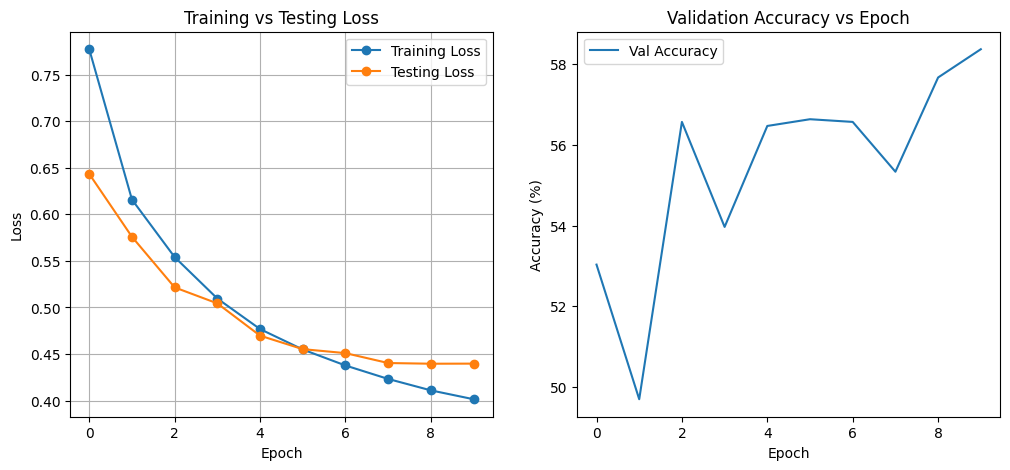

[0 1 2]
[0 1 2]
(3, 3)


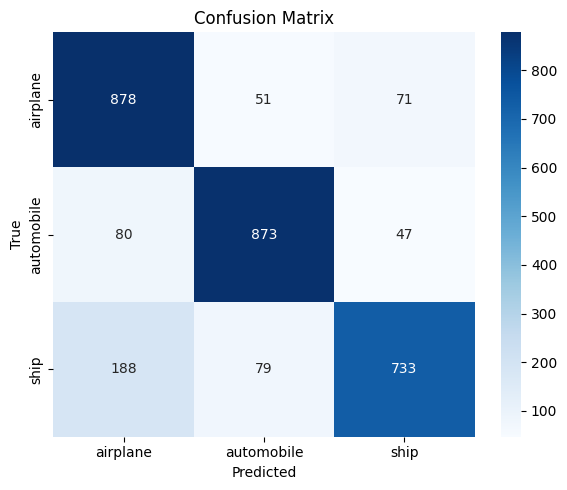

Classification Accuracy: 82.80%

Classification Report:

              precision    recall  f1-score   support

    airplane       0.77      0.88      0.82      1000
  automobile       0.87      0.87      0.87      1000
        ship       0.86      0.73      0.79      1000

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



In [ ]:
plot_training_results(train_losses, test_losses, model, filtered_testloader, Class_names,val_acc)

In [ ]:
#CNN model Task 1 and 2:
class_no = 10
class CNN2(nn.Module):
  #define layers
  #notes: CIFAR 10 dataset is 32x32 photos with 3 color channels
  def __init__(self, input_dim = 3, hidden_dim = (16*16*16), out_dim = class_no):
    super(CNN2, self).__init__()
    self.conv1 = nn.Conv2d(input_dim, 16, 3, padding='same')
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(2,2) #due to maxpool2d, the 32x32 becomes 16x16 ergo hidden_dim = 16x16x16(filters)


    self.fc = nn.Linear(hidden_dim, class_no)

    self.softmax = nn.Softmax(dim=1)
  #define forward pass
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = torch.flatten(x,1)
    x = self.fc(x)
    #x = self.softmax(x)
    return x #softmax must be added after loss as for loss calculation with corss entropy expects raw logits not weighted softmax
#Task 1 training params(3 class): adam opt, cross entropy loss, batch training 64, 10 epochs
#Task 2 training  (10class):

In [ ]:
#Task 2 training and testing loops
model = CNN2()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
train_losses = []
test_losses = []
epochs = 10
val_acc = []
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_loss = 0.0
    total, correct = 0.0,0.0
    # Validation
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_test_loss = running_loss / len(filtered_testloader) # Changed from testloader
    val_acc.append(100 * correct / total)
    avg_test_loss = running_loss / len(testloader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Val Acc: {val_acc[-1]:.2f}")

print("Training complete.")

Epoch 1/10 | Train Loss: 1.5665 | Test Loss: 1.3820 | Val Acc: 51.98
Epoch 2/10 | Train Loss: 1.3012 | Test Loss: 1.2580 | Val Acc: 55.87
Epoch 3/10 | Train Loss: 1.2147 | Test Loss: 1.2340 | Val Acc: 56.32
Epoch 4/10 | Train Loss: 1.1631 | Test Loss: 1.2094 | Val Acc: 57.16
Epoch 5/10 | Train Loss: 1.1190 | Test Loss: 1.1914 | Val Acc: 58.80
Epoch 6/10 | Train Loss: 1.0860 | Test Loss: 1.2341 | Val Acc: 57.50
Epoch 7/10 | Train Loss: 1.0557 | Test Loss: 1.1527 | Val Acc: 59.33
Epoch 8/10 | Train Loss: 1.0324 | Test Loss: 1.1344 | Val Acc: 60.88
Epoch 9/10 | Train Loss: 1.0049 | Test Loss: 1.1316 | Val Acc: 60.88
Epoch 10/10 | Train Loss: 0.9889 | Test Loss: 1.1060 | Val Acc: 61.50
Training complete.


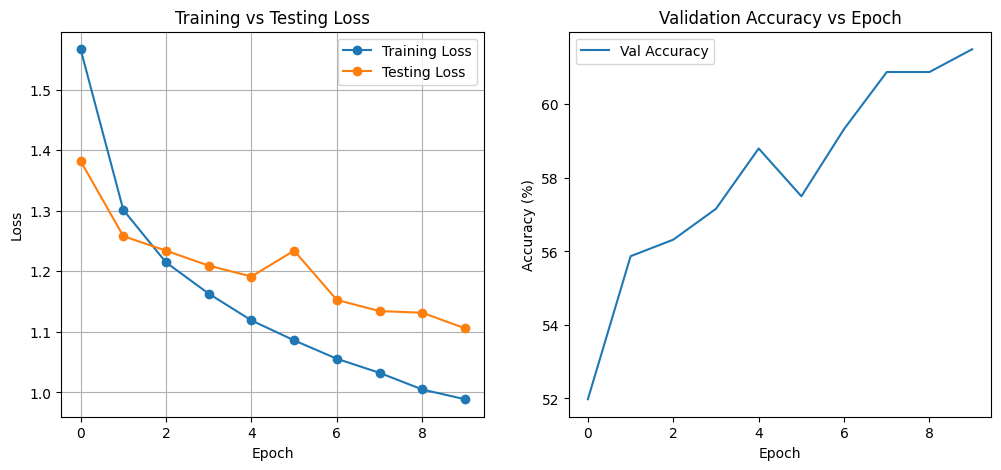

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
(10, 10)


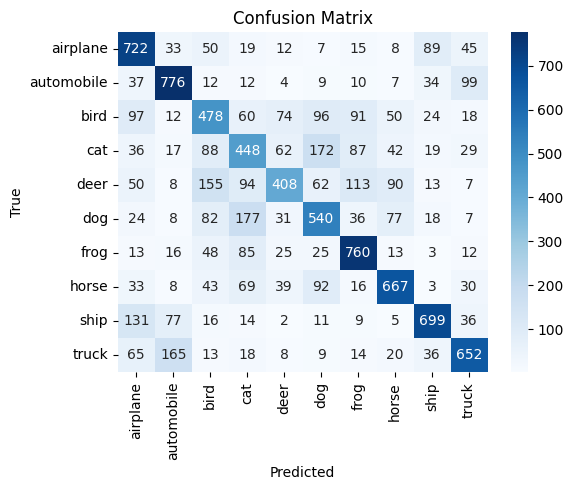

Classification Accuracy: 61.50%

Classification Report:

              precision    recall  f1-score   support

    airplane       0.60      0.72      0.65      1000
  automobile       0.69      0.78      0.73      1000
        bird       0.49      0.48      0.48      1000
         cat       0.45      0.45      0.45      1000
        deer       0.61      0.41      0.49      1000
         dog       0.53      0.54      0.53      1000
        frog       0.66      0.76      0.71      1000
       horse       0.68      0.67      0.67      1000
        ship       0.75      0.70      0.72      1000
       truck       0.70      0.65      0.67      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.61     10000
weighted avg       0.62      0.61      0.61     10000



In [ ]:
plot_training_results(train_losses, test_losses, model, testloader, full_trainset.classes,val_acc)

In [ ]:
#CNN model Task 3 adding CNN layer and RELU activation before FC1 and adding batchnormalization after conv1 so like x = batchnorm(self.conv1(x)):
class CNN3(nn.Module):
  #define layers
  #notes: CIFAR 10 dataset is 32x32 photos with 3 color channels
  class_no = 10
  def __init__(self, input_dim = 3, hidden_dim = (32*16*16), out_dim = class_no):
    super(CNN3, self).__init__()


    self.conv1 = nn.Conv2d(input_dim, 16, 3, padding='same')
    self.batchnorm = nn.BatchNorm2d(16)
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(2,2) #due to maxpool2d, the 32x32 becomes 16x16 ergo hidden_dim = 16x16x3


    self.conv2 = nn.Conv2d(16,32,3,padding='same')
    self.batchnorm2 = nn.BatchNorm2d(32)

    #insert conv2(16x16x16,32 filters) and reuse relu after conv2 before fc
    self.fc = nn.Linear(hidden_dim, class_no)
    self.softmax = nn.Softmax(dim=1)
    # add this after the loss as crossentropy will not work great with weighted softmax logits self.softmax = nn.Softmax(dim=1) for task 5 to improve performance
  #define forward pass
  def forward(self, x):
    x = self.relu(self.batchnorm(self.conv1(x)))
    x = self.pool(x)

    x = self.relu(self.batchnorm2(self.conv2(x)))

    x = torch.flatten(x,1)
    x = self.fc(x)
    #x = self.softmax(x)
    return x #softmax must be added after loss as for loss calculation with corss entropy expects raw logits not weighted softmax

    #same training parameters as task 2


In [ ]:
#Task 3 training and testing loops
model = CNN3()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
train_losses = []
test_losses = []
epochs = 10
val_acc
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_loss = 0.0
    total, correct = 0.0,0.0
    # Validation
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc.append(100 * correct / total)
    avg_test_loss = running_loss / len(testloader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}| Val Acc: {val_acc[-1]:.2f}")

print("Training complete.")

Epoch 1/10 | Train Loss: 1.2686 | Test Loss: 1.1448| Val Acc: 60.37
Epoch 2/10 | Train Loss: 0.9383 | Test Loss: 1.0491| Val Acc: 63.68
Epoch 3/10 | Train Loss: 0.8301 | Test Loss: 0.9775| Val Acc: 66.77
Epoch 4/10 | Train Loss: 0.7496 | Test Loss: 0.9610| Val Acc: 67.69
Epoch 5/10 | Train Loss: 0.6899 | Test Loss: 0.9870| Val Acc: 66.44
Epoch 6/10 | Train Loss: 0.6379 | Test Loss: 1.0747| Val Acc: 65.73
Epoch 7/10 | Train Loss: 0.5919 | Test Loss: 0.9719| Val Acc: 68.13
Epoch 8/10 | Train Loss: 0.5500 | Test Loss: 1.0651| Val Acc: 66.66
Epoch 9/10 | Train Loss: 0.5113 | Test Loss: 1.1925| Val Acc: 63.76
Epoch 10/10 | Train Loss: 0.4746 | Test Loss: 1.0339| Val Acc: 67.79
Training complete.


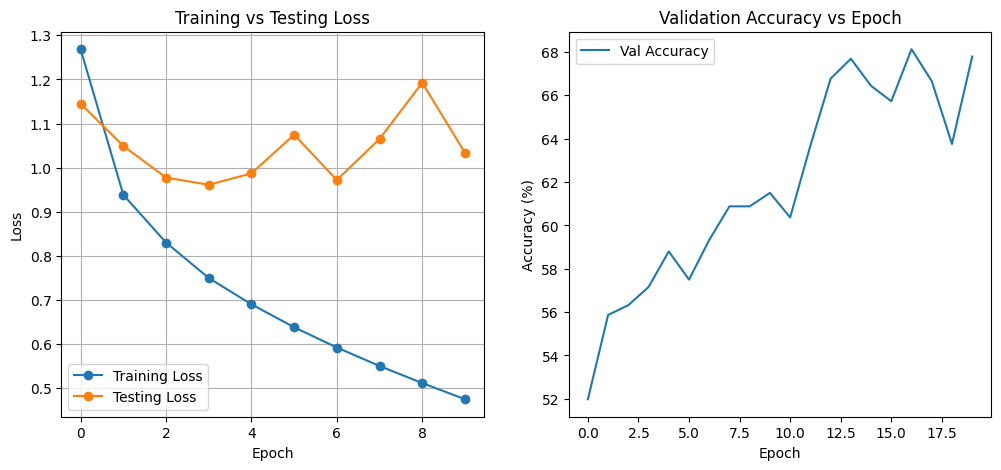

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
(10, 10)


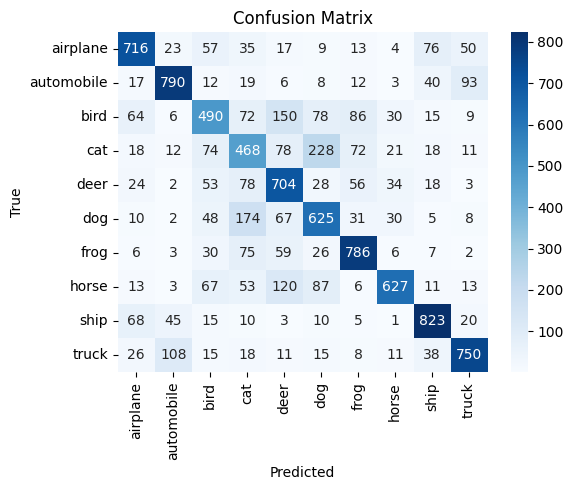

Classification Accuracy: 67.79%

Classification Report:

              precision    recall  f1-score   support

    airplane       0.74      0.72      0.73      1000
  automobile       0.79      0.79      0.79      1000
        bird       0.57      0.49      0.53      1000
         cat       0.47      0.47      0.47      1000
        deer       0.58      0.70      0.64      1000
         dog       0.56      0.62      0.59      1000
        frog       0.73      0.79      0.76      1000
       horse       0.82      0.63      0.71      1000
        ship       0.78      0.82      0.80      1000
       truck       0.78      0.75      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



In [ ]:
#Task 3 results
plot_training_results(train_losses, test_losses, model, testloader, full_trainset.classes,val_acc)

In [ ]:
#CNN model Task 4: adding dropot layer before self.fc=nn.linear layer dropout p=0.5
#add mechanism to estimate prediction uncertainty: (define prediction uncertainty) (one method is performing multiple forward passes with smae img whith dropout active in inference)
class CNN4(nn.Module):
  #define layers
  #notes: CIFAR 10 dataset is 32x32 photos with 3 color channels
  class_no = 10
  def __init__(self, input_dim = 3, hidden_dim = (32*16*16), out_dim = class_no):
    super(CNN4, self).__init__()


    self.conv1 = nn.Conv2d(input_dim, 16, 3, padding='same')
    self.batchnorm = nn.BatchNorm2d(16)
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(2,2) #due to maxpool2d, the 32x32 becomes 16x16 ergo hidden_dim = 16x16x3


    self.conv2 = nn.Conv2d(16,32,3,padding='same')
    self.batchnorm2 = nn.BatchNorm2d(32)

    #insert conv2(16x16x16,32 filters) and reuse relu after conv2 before fc
    self.fc = nn.Linear(hidden_dim, class_no)

    self.softmax = nn.Softmax(dim=1)
    self.dropout = nn.Dropout(p=0.5)
    # add this after the loss as crossentropy will not work great with weighted softmax logits self.softmax = nn.Softmax(dim=1)
  #define forward pass
  def forward(self, x):
    x = self.relu(self.batchnorm(self.conv1(x)))
    x = self.pool(x)

    x = self.relu(self.batchnorm2(self.conv2(x)))

    x = torch.flatten(x,1)
    x = self.dropout(x)
    x = self.fc(x)
    #x = self.softmax(x)
    return x #softmax must be added after loss as for loss calculation with corss entropy expects raw logits not weighted softmax

    #same training parameters as task 2


In [ ]:
#Task 4 training and testing loops
model = CNN4()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
train_losses = []
test_losses = []
epochs = 10
val_acc = []
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_loss = 0.0
    total, correct = 0.0,0.0
    # Validation
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc.append(100 * correct / total)
    avg_test_loss = running_loss / len(testloader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}| Val Acc: {val_acc[-1]:.2f}")

print("Training complete.")

def mc_dropout_predict(model, images, passes=30):
    model.train()  # <-- keep dropout ON
    preds = []

    with torch.no_grad():
        for _ in range(passes):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds.append(probs.unsqueeze(0))  # shape: (1, batch, classes)

    preds = torch.cat(preds, dim=0)  # shape: (passes, batch, classes)

    mean_pred = preds.mean(dim=0)    # average prediction
    uncertainty = preds.var(dim=0)   # predictive variance

    return mean_pred, uncertainty

model.eval()  # optional, but safe

images, labels = next(iter(testloader))
mean_pred, uncertainty = mc_dropout_predict(model, images, passes=50)
print(mean_pred.shape, uncertainty.shape)

Epoch 1/10 | Train Loss: 1.4104 | Test Loss: 1.1415| Val Acc: 59.07
Epoch 2/10 | Train Loss: 1.0719 | Test Loss: 1.2579| Val Acc: 57.69
Epoch 3/10 | Train Loss: 0.9696 | Test Loss: 1.0236| Val Acc: 64.38
Epoch 4/10 | Train Loss: 0.9135 | Test Loss: 0.9356| Val Acc: 67.35
Epoch 5/10 | Train Loss: 0.8774 | Test Loss: 0.9765| Val Acc: 66.13
Epoch 6/10 | Train Loss: 0.8451 | Test Loss: 0.9450| Val Acc: 67.12
Epoch 7/10 | Train Loss: 0.8252 | Test Loss: 1.0768| Val Acc: 63.79
Epoch 8/10 | Train Loss: 0.7977 | Test Loss: 0.9090| Val Acc: 68.41
Epoch 9/10 | Train Loss: 0.7824 | Test Loss: 0.9013| Val Acc: 69.00
Epoch 10/10 | Train Loss: 0.7691 | Test Loss: 0.9636| Val Acc: 66.95
Training complete.
torch.Size([64, 10]) torch.Size([64, 10])


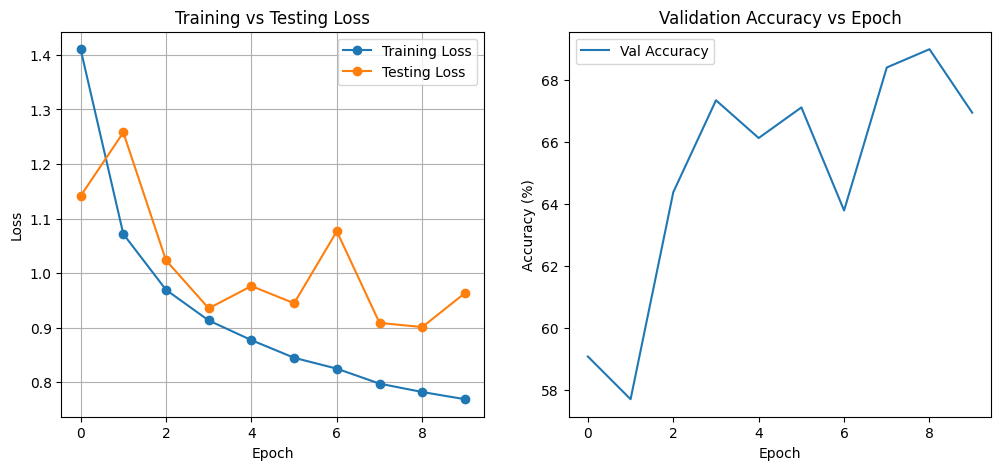

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
(10, 10)


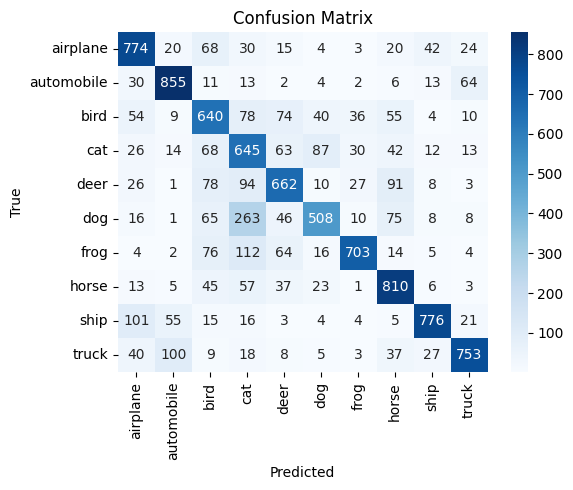

Classification Accuracy: 71.26%

Classification Report:

              precision    recall  f1-score   support

    airplane       0.71      0.77      0.74      1000
  automobile       0.81      0.85      0.83      1000
        bird       0.60      0.64      0.62      1000
         cat       0.49      0.65      0.55      1000
        deer       0.68      0.66      0.67      1000
         dog       0.72      0.51      0.60      1000
        frog       0.86      0.70      0.77      1000
       horse       0.70      0.81      0.75      1000
        ship       0.86      0.78      0.82      1000
       truck       0.83      0.75      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.73      0.71      0.71     10000
weighted avg       0.73      0.71      0.71     10000



In [ ]:
#Task 4 results
plot_training_results(train_losses, test_losses, model, testloader, full_trainset.classes,val_acc)

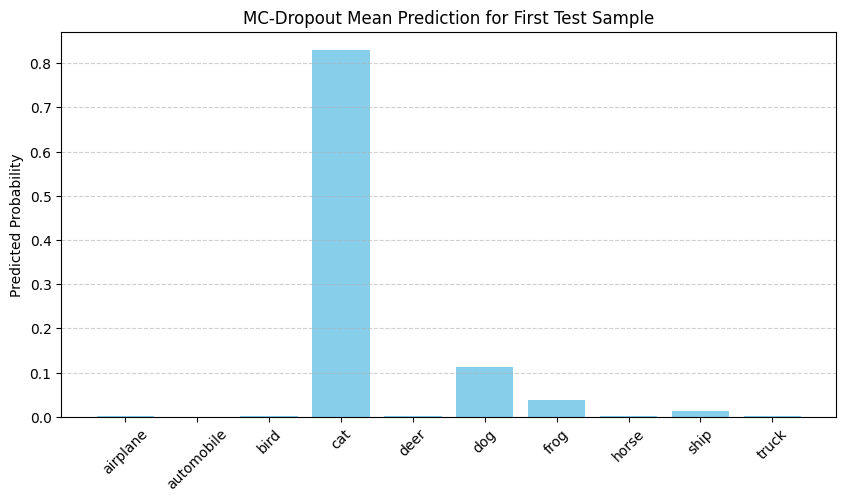

In [ ]:
cifar10_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]
probs = mean_pred[0].cpu().numpy()   # first sample
classes = list(range(len(probs)))
plt.figure(figsize=(10,5))
plt.bar(cifar10_classes, probs, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Predicted Probability")
plt.title("MC-Dropout Mean Prediction for First Test Sample")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

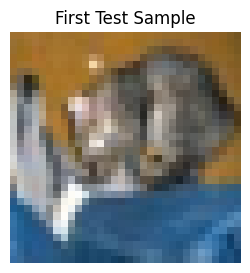

In [ ]:
img = images[0].cpu()

img = img.clamp(0,1)
img_np = img.permute(1, 2, 0).numpy()

plt.figure(figsize=(3,3))
plt.imshow(img_np)
plt.axis("off")
plt.title("First Test Sample")
plt.show()


In [ ]:
#Task % Improved network with Resnet and expanded feature mapping (GPU train only)
import torch, torchvision, time
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Residual Block with optional channel expansion
class ResBlock(nn.Module):
    def __init__(self, in_chans, out_chans, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_chans, out_chans, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_chans)
        self.conv2 = nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_chans)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_chans != out_chans:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_chans, out_chans, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_chans)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

# ResNet-10 style model
class NetResDeep(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.layer1 = self._make_layer(32, 32, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(32, 64, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_chans, out_chans, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(ResBlock(in_chans, out_chans, stride=s))
            in_chans = out_chans
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        return self.fc(out)




# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = NetResDeep().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses, val_losses, val_accs = [], [], []
start_time = time.time()

for epoch in range(10):
    net.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(trainloader))

    # Validation
    net.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(val_loss / len(testloader))
    val_accs.append(100 * correct / total)
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Val Acc={val_accs[-1]:.2f}%")

print(f"Training time: {time.time() - start_time:.2f} seconds")


Epoch 1: Train Loss=1.2438, Val Loss=1.1643, Val Acc=60.88%
Epoch 2: Train Loss=0.7698, Val Loss=0.7551, Val Acc=73.38%
Epoch 3: Train Loss=0.5893, Val Loss=0.7149, Val Acc=75.71%
Epoch 4: Train Loss=0.4771, Val Loss=0.6564, Val Acc=78.00%
Epoch 5: Train Loss=0.3818, Val Loss=0.6108, Val Acc=79.50%
Epoch 6: Train Loss=0.3015, Val Loss=0.5297, Val Acc=83.07%
Epoch 7: Train Loss=0.2234, Val Loss=0.6140, Val Acc=81.84%
Epoch 8: Train Loss=0.1668, Val Loss=0.6846, Val Acc=81.30%
Epoch 9: Train Loss=0.1318, Val Loss=0.7443, Val Acc=80.74%
Epoch 10: Train Loss=0.0962, Val Loss=0.7479, Val Acc=81.77%
Training time: 48.73 seconds



Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.89      0.84      1000
  automobile       0.95      0.85      0.90      1000
        bird       0.71      0.78      0.74      1000
         cat       0.64      0.73      0.68      1000
        deer       0.87      0.76      0.81      1000
         dog       0.80      0.68      0.73      1000
        frog       0.87      0.84      0.85      1000
       horse       0.92      0.83      0.87      1000
        ship       0.86      0.89      0.87      1000
       truck       0.84      0.93      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000

Classification Accuracy: 81.77%


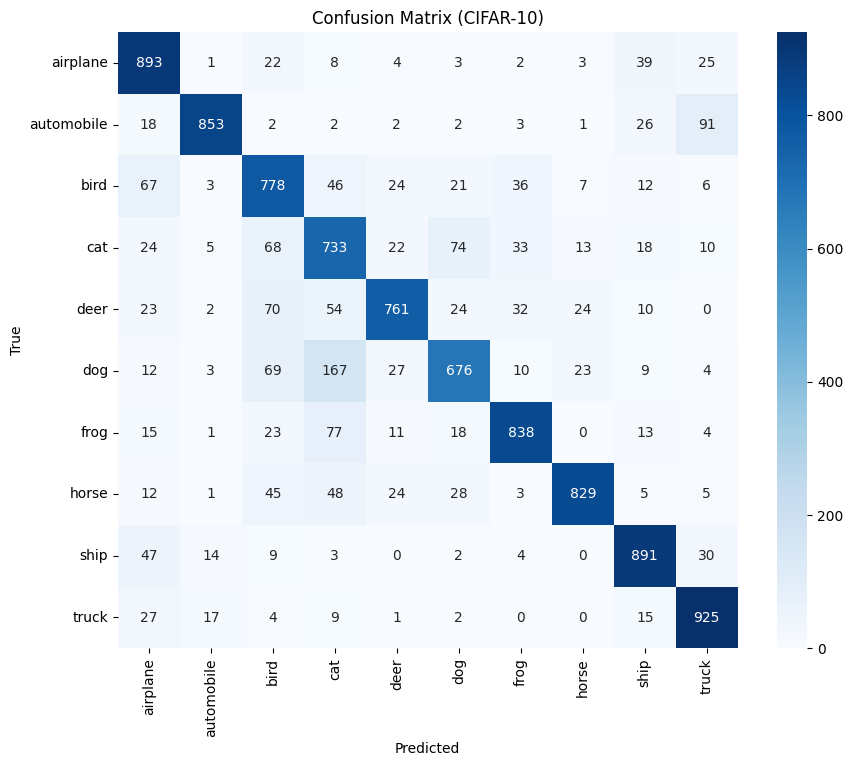

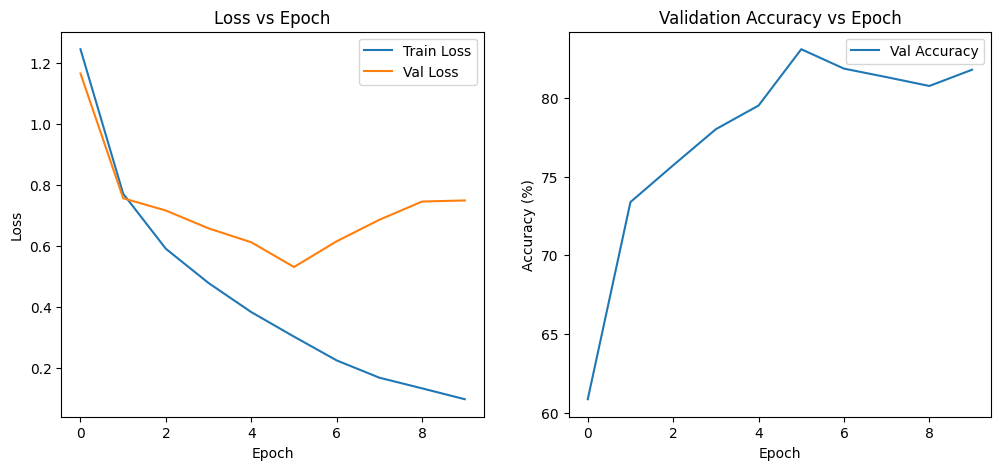

In [ ]:
# Final Evaluation
net.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_trainset.classes))
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = (all_preds == all_labels).mean() * 100
print(f"Classification Accuracy: {accuracy:.2f}%")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_trainset.classes, yticklabels=full_trainset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CIFAR-10)")
plt.show()

# Plot Loss and Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss vs Epoch')
plt.subplot(1,2,2)
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy vs Epoch')
plt.show()


In [ ]:
def mc_dropout_predict(model, images, passes=30): #reinserted as I only utilized cells required to run task 5 for gpu use
    model.train()  # <-- keep dropout ON
    preds = []

    with torch.no_grad():
        for _ in range(passes):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds.append(probs.unsqueeze(0))  # shape: (1, batch, classes)

    preds = torch.cat(preds, dim=0)  # shape: (passes, batch, classes)

    mean_pred = preds.mean(dim=0)    # average prediction
    uncertainty = preds.var(dim=0)   # predictive variance

    return mean_pred, uncertainty
mean_pred, uncertainty = mc_dropout_predict(net, inputs, passes=50)
print(mean_pred.shape, uncertainty.shape)

torch.Size([16, 10]) torch.Size([16, 10])


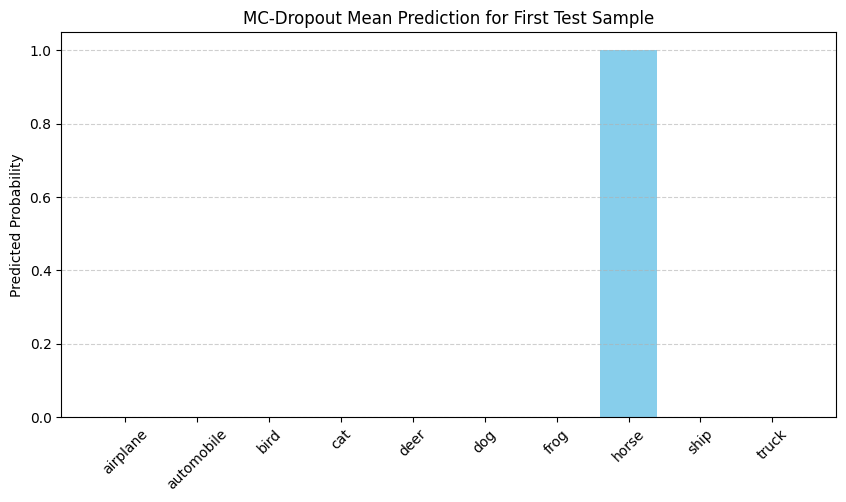

In [ ]:
cifar10_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]
probs = mean_pred[0].cpu().numpy()   # first sample
classes = list(range(len(probs)))
plt.figure(figsize=(10,5))
plt.bar(cifar10_classes, probs, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Predicted Probability")
plt.title("MC-Dropout Mean Prediction for First Test Sample")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()